### Loading Required Datasets
---

In [107]:
import pandas as pd

df1 = pd.read_csv('deliveries.csv')
df2 = pd.read_csv('matches.csv')

### About Both datasets
---

In [108]:
print('Shape of deliveries dataset : ',df1.shape)
print('Shape of matches dataset : ',df2.shape)

Shape of deliveries dataset :  (179078, 21)
Shape of matches dataset :  (756, 18)


In [109]:
print('List of datatypes in deliveries dataset\n',df1.dtypes)

List of datatypes in deliveries dataset
 match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batsman             object
non_striker         object
bowler              object
is_super_over        int64
wide_runs            int64
bye_runs             int64
legbye_runs          int64
noball_runs          int64
penalty_runs         int64
batsman_runs         int64
extra_runs           int64
total_runs           int64
player_dismissed    object
dismissal_kind      object
fielder             object
dtype: object


In [110]:
print('List of datatypes in matches dataset\n',df2.dtypes)

List of datatypes in matches dataset
 id                  int64
Season             object
city               object
date               object
team1              object
team2              object
toss_winner        object
toss_decision      object
result             object
dl_applied          int64
winner             object
win_by_runs         int64
win_by_wickets      int64
player_of_match    object
venue              object
umpire1            object
umpire2            object
umpire3            object
dtype: object


In [111]:
print('Null values in deliveries dataset\n',df1.isnull().sum())

Null values in deliveries dataset
 match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64


In [112]:
print('Null values in matches dataset\n',df2.isnull().sum())

Null values in matches dataset
 id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64


### Summary report of both datasets
---
**deliveries.csv**
- It is a large dataset with around 180K records and 21 columns 
- It mostly have coloumns of int data types and some of the columns are objects
- 3 columns in this dataset have large amount of null values

**matches.csv**
- It is compartively small dataset with 756 records and 18 columns
- It mostly contains object datatypes columns
- It has few null values in some columns like `umpire3` 

In [113]:
balls_faced_by_batsman = df1.groupby('batsman')['batsman'].count()
runs_scored = df1.groupby('batsman')['batsman_runs'].sum()
strike_rate = (runs_scored/balls_faced_by_batsman)*100

total_matches_played = df1.groupby('batsman')['match_id'].nunique()
out_count = df1.groupby('batsman')['player_dismissed'].count()
batting_average = runs_scored/out_count.replace(0,1)

batsman_stats = pd.concat([runs_scored,strike_rate,batting_average],axis=1)
batsman_stats.columns = ['runs_scored','strike_rate','batting_average']

top_10 = batsman_stats.sort_values(by = 'runs_scored' ,ascending = False).head(10)

print('Top Batsman Analysis : \n')
print(top_10)

Top Batsman Analysis : 

                runs_scored  strike_rate  batting_average
batsman                                                  
V Kohli                5434   129.042983        35.750000
SK Raina               5415   133.902077        33.633540
RG Sharma              4914   128.773585        30.333333
DA Warner              4741   139.523249        41.587719
S Dhawan               4632   122.669492        33.810219
CH Gayle               4560   145.640370        41.454545
MS Dhoni               4477   134.930681        37.940678
RV Uthappa             4446   127.319588        28.318471
AB de Villiers         4428   148.740343        42.576923
G Gambhir              4223   119.835414        31.281481


In [114]:
dismissal = df1[ (df1['dismissal_kind'].notna()) & (df1['dismissal_kind'] != 'run out')]
wicket_takers = dismissal.groupby('bowler')['dismissal_kind'].count()

runs = df1.groupby('bowler')['total_runs'].sum()
balls = df1.groupby('bowler')['ball'].count()

economy_df = pd.concat([runs, balls, wicket_takers], axis=1)
economy_df.columns = ['runs_conceded', 'balls_bowled','wickets_taken']

economy_df = economy_df[economy_df['balls_bowled'] >= 200]
economy_df['economy_rate'] = (economy_df['runs_conceded'] / (economy_df['balls_bowled'] / 6))

top_economy = economy_df.sort_values(by='wickets_taken',ascending=False).head(10)

print('Top Bowlers Analysis : \n')
print(top_economy)

Top Bowlers Analysis : 

                 runs_conceded  balls_bowled  wickets_taken  economy_rate
bowler                                                                   
SL Malinga                3511          2974          170.0      7.083389
A Mishra                  3850          3172          156.0      7.282472
Harbhajan Singh           4050          3451          150.0      7.041437
PP Chawla                 4153          3157          149.0      7.892936
DJ Bravo                  3733          2711          147.0      8.261896
B Kumar                   3264          2707          133.0      7.234577
R Ashwin                  3391          3016          125.0      6.746021
SP Narine                 2939          2600          122.0      6.782308
UT Yadav                  3640          2605          119.0      8.383877
RA Jadeja                 3221          2541          108.0      7.605667


In [115]:
winning = df2.groupby('winner')['id'].count()
t1_match_counts = df2['team1'].value_counts()
t2_match_counts = df2['team2'].value_counts()

matches_played_by_team = t1_match_counts.add(t2_match_counts,fill_value=0)
win_rate = (winning/matches_played_by_team)*100

top_win_rate = win_rate.sort_values(ascending=False)
print('Best Winning Rate in IPL : \n',top_win_rate)

Best Winning Rate in IPL : 
 winner
Delhi Capitals                 62.500000
Rising Pune Supergiant         62.500000
Chennai Super Kings            60.975610
Mumbai Indians                 58.288770
Sunrisers Hyderabad            53.703704
Kolkata Knight Riders          51.685393
Rajasthan Royals               51.020408
Royal Challengers Bangalore    46.666667
Kings XI Punjab                46.590909
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
dtype: float64


In [116]:
by_runs = df2[df2['win_by_runs'] > 0]
by_wickets = df2[df2['win_by_wickets'] > 0]

win_by_runs = by_runs.groupby('winner')['win_by_runs'].count()
win_by_wickets = by_wickets.groupby('winner')['win_by_wickets'].count()

win_by_runs_rate = (win_by_runs/matches_played_by_team)*100
win_by_wickets_rate = (win_by_wickets/matches_played_by_team)*100

df_win_rate = pd.concat([win_by_runs_rate,win_by_wickets_rate],axis=1)
df_win_rate.columns = ('win_by_runs_rate','win_by_wickets_rate')

print('List of teams with win rate of batting first and bowling first : \n')
print(df_win_rate)


List of teams with win rate of batting first and bowling first : 

                             win_by_runs_rate  win_by_wickets_rate
winner                                                            
Chennai Super Kings                 31.707317            29.268293
Deccan Chargers                     24.000000            14.666667
Delhi Capitals                      18.750000            37.500000
Delhi Daredevils                    15.527950            26.086957
Gujarat Lions                        3.333333            40.000000
Kings XI Punjab                     21.590909            23.863636
Kochi Tuskers Kerala                14.285714            28.571429
Kolkata Knight Riders               20.224719            31.460674
Mumbai Indians                      30.481283            26.737968
Pune Warriors                       13.043478            13.043478
Rajasthan Royals                    18.367347            31.292517
Rising Pune Supergiant              31.250000            31.25

In [117]:
toss_team_bat_win = df2[(df2['toss_winner'] == df2['winner']) & (df2['win_by_runs'] > 0)]

result = toss_team_bat_win.groupby('toss_winner')['winner'].count()

toss_win_bat_win_rate = ((result/matches_played_by_team)*100).fillna(0).sort_values(ascending=False)
print('List of teams which won the toss decided to bat first and also won the match : \n')
print(toss_win_bat_win_rate)


List of teams which won the toss decided to bat first and also won the match : 

Chennai Super Kings            18.292683
Deccan Chargers                14.666667
Rising Pune Supergiants        14.285714
Mumbai Indians                 12.834225
Rajasthan Royals                9.523810
Kolkata Knight Riders           8.988764
Sunrisers Hyderabad             7.407407
Delhi Daredevils                6.832298
Pune Warriors                   6.521739
Delhi Capitals                  6.250000
Royal Challengers Bangalore     5.000000
Kings XI Punjab                 3.409091
Gujarat Lions                   0.000000
Kochi Tuskers Kerala            0.000000
Rising Pune Supergiant          0.000000
dtype: float64


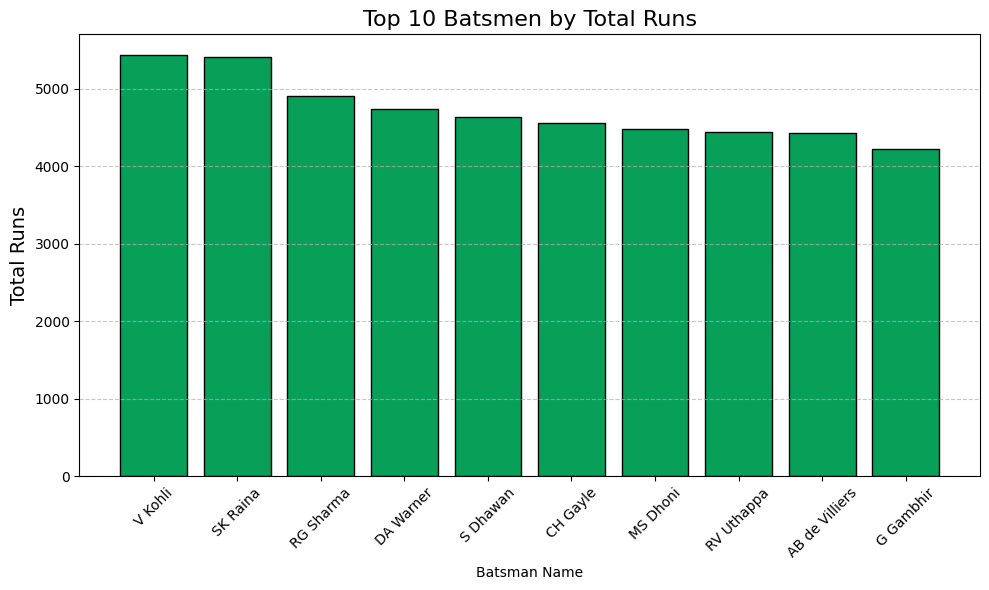

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(top_10.index, top_10['runs_scored'], color = "#08A059", edgecolor = 'black')

plt.title('Top 10 Batsmen by Total Runs',fontsize = 16)
plt.xlabel('Batsman Name')
plt.ylabel('Total Runs',fontsize = '14')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

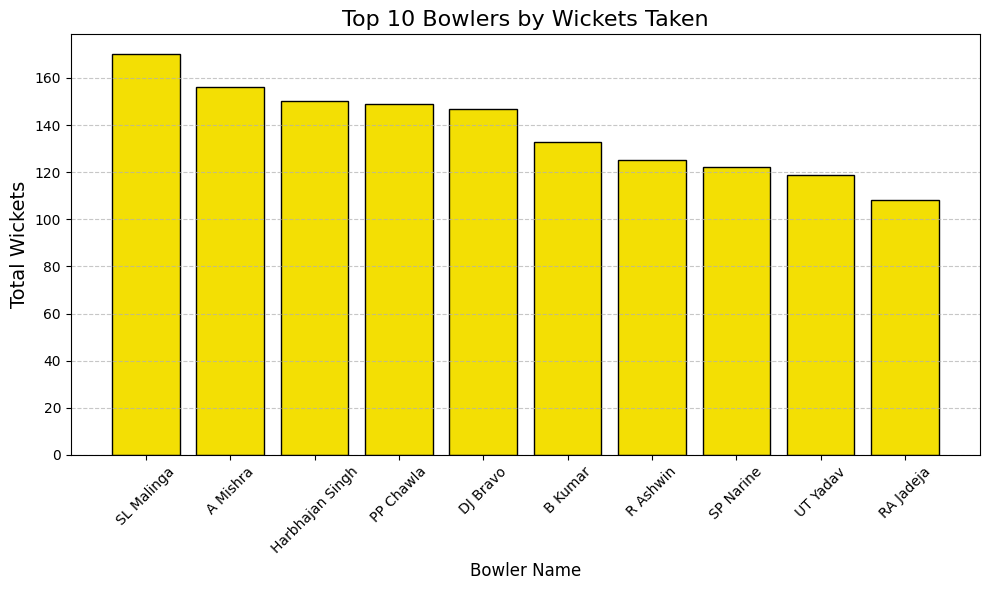

In [119]:
plt.figure(figsize=(10, 6))

plt.bar(top_economy.index, top_economy['wickets_taken'], color = "#F3DF04", edgecolor = 'black')

plt.title('Top 10 Bowlers by Wickets Taken', fontsize = 16)
plt.xlabel('Bowler Name', fontsize = 12)
plt.ylabel('Total Wickets', fontsize = 14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

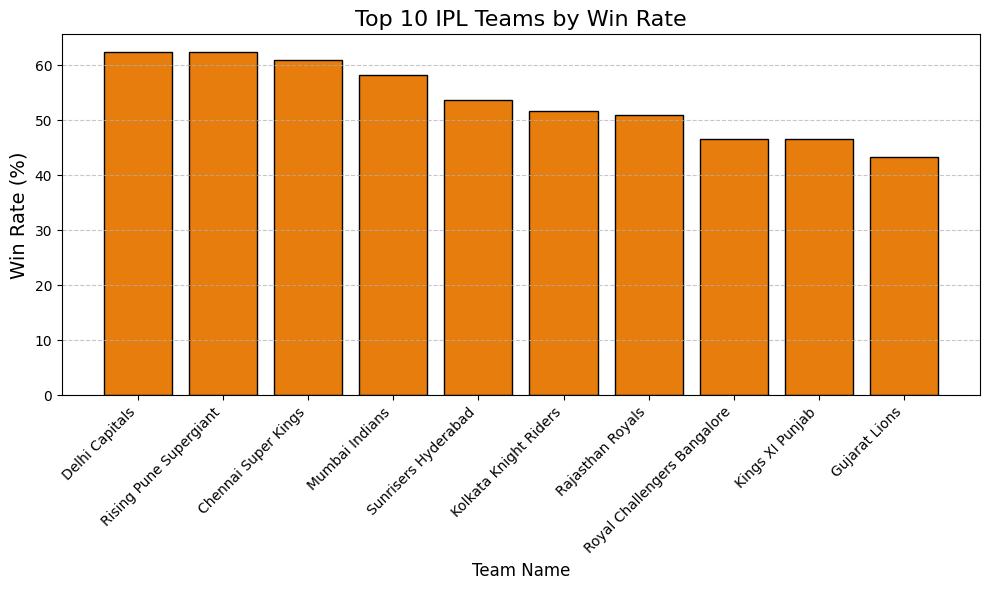

In [120]:
plt.figure(figsize=(10, 6))

plt.bar(top_win_rate.head(10).index, top_win_rate.head(10), color = "#E67D0D", edgecolor = 'black')

plt.title('Top 10 IPL Teams by Win Rate', fontsize = 16)
plt.xlabel('Team Name', fontsize = 12)
plt.ylabel('Win Rate (%)', fontsize = 14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

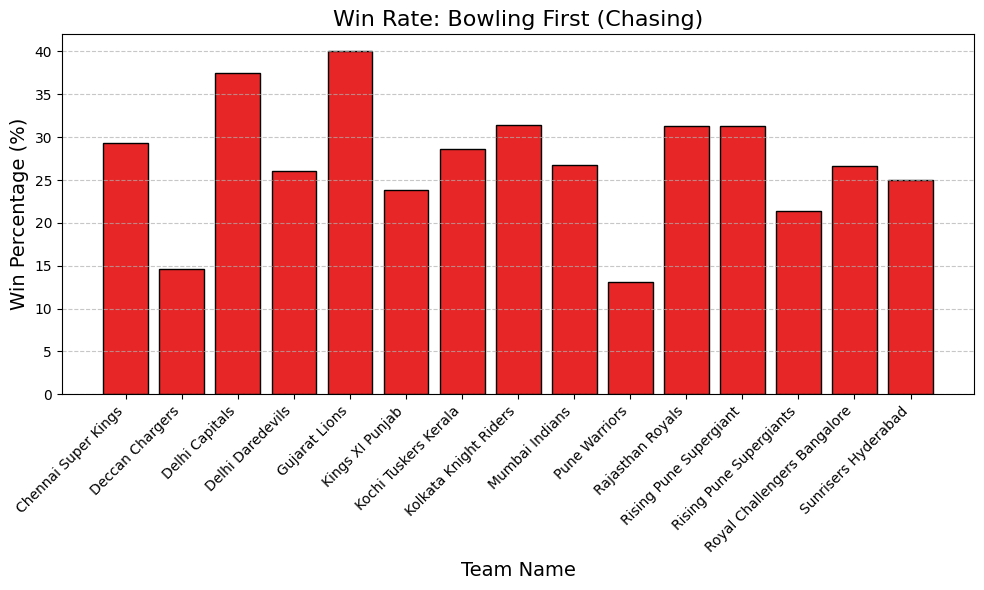

In [121]:
plt.figure(figsize=(10, 6))
plt.bar(df_win_rate.index, df_win_rate['win_by_wickets_rate'], color = "#E72727", edgecolor = 'black')

plt.title('Win Rate: Bowling First (Chasing)', fontsize = 16)
plt.xlabel('Team Name',fontsize = 14)
plt.ylabel('Win Percentage (%)', fontsize = 14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

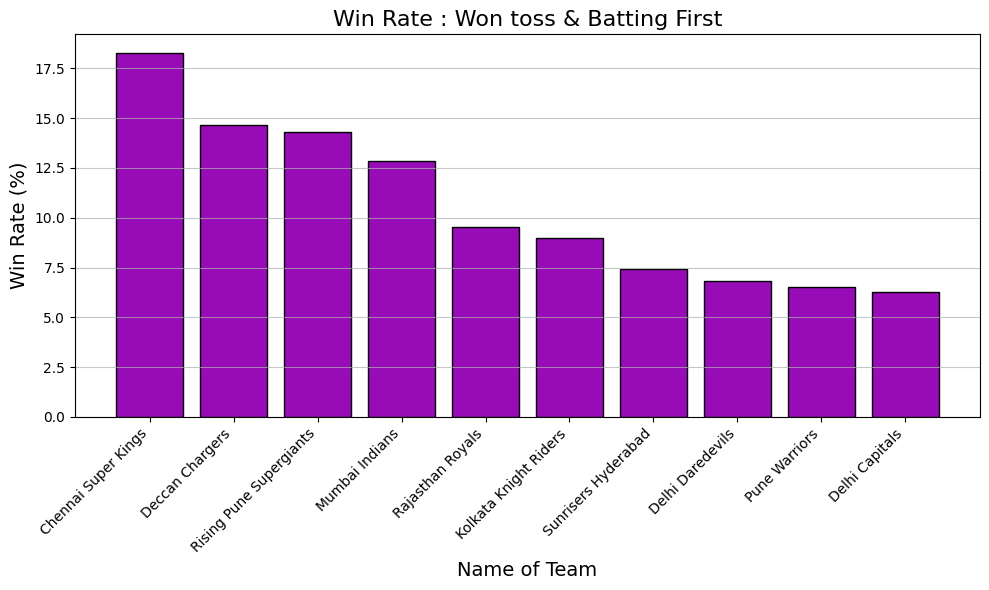

In [122]:
plt.figure(figsize=(10,6))

plt.bar(toss_win_bat_win_rate.head(10).index, toss_win_bat_win_rate.head(10), color = "#970CB6", edgecolor = 'black')

plt.title('Win Rate : Won toss & Batting First',fontsize = 16)
plt.xlabel('Name of Team', fontsize = 14)
plt.ylabel('Win Rate (%)',fontsize = 14)

plt.grid(axis = 'y', linestyle = '-', alpha = 0.7)
plt.xticks(rotation = 45, ha = 'right')

plt.tight_layout()
plt.show()